# Forecast comparison

Keep aggregate and bottom-level models separate. Read selected_model from the manifest.

Run the CLI first. Default RUN is fixture; change only after processing real data.

In [1]:
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUN = 'fixture'
OUT = ROOT / 'data/powerbi' / RUN
def read(name):
    return pd.read_parquet(OUT / (name + '.parquet'))
assert OUT.exists(), 'Run python src/run_pipeline.py --mode sample --fixture first'


,model,fold,split_role,origin,validation_start,validation_end,forecast_level,training_seconds,mae,rmse,wape,mape,bias,rmsse
0,lightgbm,1,calibration,2016-05-30,2016-05-31,2016-06-27,item_store,0.203274,1.424088,1.828264,0.456143,0.556683,0.011877,0.729950
1,moving_average,1,calibration,2016-05-30,2016-05-31,2016-06-27,item_store,0.000000,1.482462,1.949021,0.474840,0.615155,0.033365,0.762761
2,naive,1,calibration,2016-05-30,2016-05-31,2016-06-27,item_store,0.000000,1.836310,2.456163,0.588179,0.701317,-0.132507,0.959795
3,seasonal_28,1,calibration,2016-05-30,2016-05-31,2016-06-27,item_store,0.000000,1.922619,2.612356,0.615825,0.756947,0.033365,1.011740
4,seasonal_7,1,calibration,2016-05-30,2016-05-31,2016-06-27,item_store,0.000000,1.863095,2.470661,0.596759,0.714055,-0.020019,0.962639
5,ets,1,calibration,2016-05-30,2016-05-31,2016-06-27,selected_portfolio_total,0.134388,8.737021,11.234842,0.116605,0.116114,0.000452,NaN
6,sarima,1,calibration,2016-05-30,2016-05-31,2016-06-27,selected_portfolio_total,0.081025,9.676924,13.228020,0.129149,0.121237,-0.070888,NaN
7,lightgbm,2,selection,2016-06-27,2016-06-28,2016-07-25,item_store,0.708653,1.396897,1.797200,0.453485,0.537241,-0.008660,0.695481
8,moving_average,2,selection,2016-06-27,2016-06-28,2016-07-25,item_store,0.000000,1.464179,1.917655,0.475328,0.584812,0.013527,0.736732
9,naive,2,selection,2016-06-27,2016-06-28,2016-07-25,item_store,0.000000,1.889881,2.477878,0.613527,0.652715,-0.201932,0.983797


,segment_type,segment,model,mae,rmse,wape,mape,bias,rmsse
0,state_id,CA,lightgbm,1.410670,1.823416,0.451845,0.571509,0.006701,0.701424
1,state_id,TX,lightgbm,1.502197,1.892188,0.490037,0.652446,0.029765,0.766395
2,store_id,CA_1,lightgbm,1.410670,1.823416,0.451845,0.571509,0.006701,0.701424
3,store_id,TX_1,lightgbm,1.502197,1.892188,0.490037,0.652446,0.029765,0.766395
4,category_id,C0,lightgbm,1.485232,1.888006,0.463037,0.603590,0.015697,0.719038
5,category_id,C1,lightgbm,1.398837,1.796858,0.488068,0.632742,0.023568,0.764855
6,department_id,D0,lightgbm,1.628532,2.033910,0.438979,0.643309,0.028785,0.704907
7,department_id,D1,lightgbm,1.398837,1.796858,0.488068,0.632742,0.023568,0.764855
8,department_id,D2,lightgbm,1.341932,1.729839,0.496028,0.554917,-0.002250,0.732897
9,volume_segment,high,lightgbm,1.869406,2.305389,0.376233,0.574577,-0.029533,0.699585


,item_id,store_id,state_id,category_id,department_id,origin,date,date_key,horizon,model,forecast_units,scale,lower_80,upper_80,lower_95,upper_95
0,SYNTH_001,CA_1,CA,C1,D1,2016-08-22,2016-08-23,20160823,1,lightgbm,2.820314,4.803005,0.692813,4.700548,0.110703,5.632648
1,SYNTH_001,TX_1,TX,C1,D1,2016-08-22,2016-08-23,20160823,1,lightgbm,2.783168,4.312187,0.655667,4.663402,0.073557,5.595501
2,SYNTH_002,CA_1,CA,C0,D2,2016-08-22,2016-08-23,20160823,1,lightgbm,4.808288,7.490818,2.680787,6.688523,2.098678,7.620622
3,SYNTH_002,TX_1,TX,C0,D2,2016-08-22,2016-08-23,20160823,1,lightgbm,4.679982,7.046745,2.552481,6.560216,1.970371,7.492315
4,SYNTH_003,CA_1,CA,C0,D0,2016-08-22,2016-08-23,20160823,1,lightgbm,5.790452,10.001669,3.662951,7.670687,3.080841,8.602786


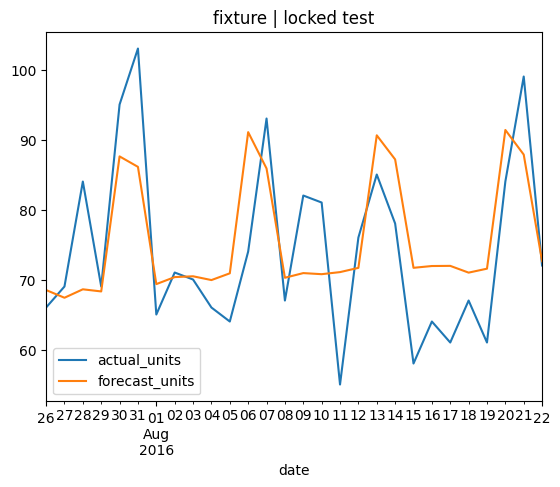

In [2]:
display(read('forecast_model_metrics'))
f = read('forecast_backtest_selected')
f.groupby('date')[['actual_units','forecast_units']].sum().plot(title=RUN + ' | locked test')
display(read('forecast_accuracy_by_segment'))
display(read('demand_forecasts_28d').head())
